In [12]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.nn.functional import normalize
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [13]:
match_stats = pd.read_csv('match_stats_2022.csv')
extended = pd.read_csv('match_stats_extended_2022.csv')
atp_2022 = pd.read_csv('atp_matches_2022.csv')


In [14]:
merged = pd.merge(match_stats, atp_2022, on=['w_ace','w_1stIn', 'w_df','w_svpt','w_1stWon','w_1stIn','l_ace','l_df','l_1stIn','l_svpt','l_1stWon','l_1stIn'], how='outer')
merged_df = pd.merge(merged, extended, on='Match', how='outer')
df = merged_df[['Place_x','surface','winner_name','winner_rank_points','W Serve Rating','W Return Rating','W Winners','W Unforced','W Points','loser_name','loser_rank_points','L Serve Rating','L Return Rating','L Winners','L Unforced','L Points']].copy()
df.insert(9,'W Forced',df['L Points']-df['L Winners']-df['W Unforced'])
df['L Forced']=df['W Points']-df['W Winners']-df['L Unforced']
df.dropna(inplace=True)
df.columns=['Place','Surface','p_name','p_rank_points','p_serve_rating','p_return_rating','p_winners','p_unforced','p_points','p_forced','o_name','o_rank_points','o_serve_rating','o_return_rating','o_winners','o_unforced','o_points','o_forced']
df.insert(0,'win',1)
loser_df=df.copy()
loser_df['win']=0
loser_df.iloc[:, -8:],loser_df.iloc[:,3:11]=loser_df.iloc[:,3:11],loser_df.iloc[:, -8:]
df=pd.concat([df,loser_df],axis=0)
df = df.sample(frac=1).reset_index(drop=True)
# temp = df[['Place_x','surface','loser_name','loser_rank_points','L Serve Rating','L Return Rating','L Winners','L Unforced']]
# temp.columns = ['Place_x','surface','winner_name','winner_rank_points','W Serve Rating','W Return Rating','W Winners','W Unforced']
# df.drop(['loser_name','loser_rank_points','L Serve Rating','L Return Rating','L Winners','L Unforced'], axis=1, inplace=True)
# df.insert(0, 'win', 1)
# temp.insert(0,'win',0)
# df = pd.concat([df, temp], ignore_index=True)
# df.columns=['Win','Place_x','Surface','Name','Rank_points','Serve_rating','Return_rating','Winners','Unforced']


In [15]:
columns_transform=['p_return_rating','p_serve_rating','p_unforced','p_winners','o_return_rating','o_serve_rating','o_unforced','o_winners']
n=len(columns_transform)//2
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()
data=pd.DataFrame(standard_scaler.fit_transform(df[columns_transform]))
for i in range(n):
  data[i]=data[i]-data[n+i]
data=pd.DataFrame(min_max_scaler.fit_transform(data.iloc[:, :n]))
x_train, x_test, y_train, y_test = train_test_split(data, df['win'], test_size=0.2, random_state=42)

In [16]:
class TennisDataset(Dataset):
    def __init__(self, x,y):
      self.x=torch.tensor(x.values.reshape(-1,n)).float()
      self.y=torch.tensor(y.values).long()
    def __len__(self):
        return self.x.size(dim=0)
    def __getitem__(self, index):
        return self.x[index],self.y[index]
train_ds = TennisDataset(x_train,y_train)
test_ds = TennisDataset(x_test,y_test)
x_test,y_test=test_ds[:]
print(df.loc[9])
print(len(train_ds))

win                             0
Place                   stockholm
Surface                      Hard
p_name                 Elias Ymer
p_rank_points               437.0
p_serve_rating              274.0
p_return_rating             138.0
p_winners                    52.0
p_unforced                   27.0
p_points                    109.0
p_forced                     39.0
o_name             Frances Tiafoe
o_rank_points              2195.0
o_serve_rating              265.0
o_return_rating             125.0
o_winners                    42.0
o_unforced                   17.0
o_points                    108.0
o_forced                     40.0
Name: 9, dtype: object
1937


In [17]:
batches=10
train_dl = DataLoader(train_ds, batches)

In [18]:
L = nn.CrossEntropyLoss()
class match_prediction_network(nn.Module):
    def __init__(self,in_features=4):
        super().__init__()
        self.Matrix1 = nn.Linear(in_features,10)
        self.Matrix2 = nn.Linear(10,in_features)
        self.Matrix3 = nn.Linear(in_features,2)
        self.R1 = nn.ReLU()
        self.R2=nn.ReLU()
        self.S=nn.Sigmoid()
    def forward(self,x):
        x = self.R1(self.Matrix1(x))
        x = self.R2(self.Matrix2(x))
        x = self.Matrix3(x)
        return x
f = match_prediction_network()

In [19]:
def train_model(dl, n_epochs=5):
    # Optimization
    opt = SGD(f.parameters(), lr=0.05)
    # Train model
    losses = []
    epochs=[]
    for epoch in range(n_epochs):
        print(f'Epoch {epoch}')
        for i, (x, y) in enumerate(dl):
            # Update the weights of the network
            y_pred = f(x)
            loss_value = L(y_pred, y)
            opt.zero_grad()
            loss_value.backward()
            opt.step()
            # Store training data
            losses.append(loss_value.item())
        epochs.append(np.mean(losses[-len(dl)]))
    return losses,epochs

In [20]:
loss_data,epoch_data = train_model(train_dl)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4


In [21]:
print(epoch_data)

[np.float64(0.6944644451141357), np.float64(0.6917330026626587), np.float64(0.6856115460395813), np.float64(0.6411116123199463), np.float64(0.30435630679130554)]


Text(0.5, 0, 'Epoch')

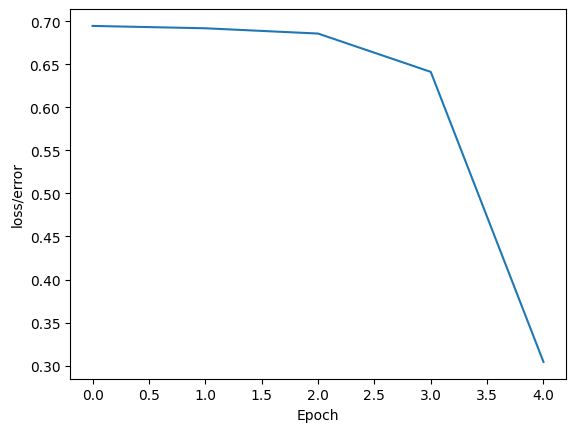

In [22]:
plt.plot(epoch_data)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

In [23]:
# checking loss and accuracy on test
f.eval()
accuracy=0
with torch.no_grad():
  y_eval = f(x_test)
  loss = L(y_eval,y_test)
  for i in range(len(test_ds)):
    y_pred=f(test_ds[i][0])
    if y_pred.argmax().item() == test_ds[i][1]:
      accuracy+=1
print(accuracy/len(test_ds))
print(test_ds[0][1])

0.9051546391752577
tensor(0)


In [24]:
#try on own data
def test_model(input_stats):
  x=pd.DataFrame(input_stats)
  x.columns=columns_transform
  x = pd.DataFrame(standard_scaler.transform(x))
  for i in range(n):
    x[i]=x[i]-x[n+i]
  x=pd.DataFrame(min_max_scaler.transform(x.iloc[:, :n]))
  x=torch.tensor(x.values.reshape(-1,n)).float()
  y_pred = f((x))
  for i in y_pred:
    if y_pred.argmax().item()==1:
      print("Player 1 will win")
    else:
      (print("Player 2 will win"))
print(test_model([[1,2,3,4,5,6,7,8],[1,2,3,4,5,6,7,8]]))




Player 1 will win
Player 1 will win
None


In [25]:
def rank_transform(self):
        scaler = StandardScaler()
        rank = pd.concat([self.ds['winner_rank_points'],self.ds['loser_rank_points']],ignore_index=True)
        rank = rank.to_frame()
        scaled_data = scaler.fit_transform(rank)
        self.ds['winner_rank_points']=scaled_data[:len(self.ds)]
        self.ds['loser_rank_points']=scaled_data[len(self.ds):]
# rank = pd.concat([df['winner_rank_points'],df['loser_rank_points']],ignore_index=True)
# rank = rank.to_frame()
# test1=StandardScaler()
# r = test1.fit_transform(rank)
# print(train_ds[1])
# test = df[columns_transform]
# test=test.values.reshape(-1,1)
# s = atp_2022_rankings['Points'].to_frame()
# scaler= StandardScaler()
# scaler.fit(s)
# rank = scaler.transform(rank)
# test=pd.DataFrame()